In [1]:
import pyWistom

In [2]:
from wistomconfig import HOST, PORT, USER_ID, PASSWORD
client = pyWistom.WistomClient(HOST, PORT, USER_ID, PASSWORD)
client.connect()
client.login()


{'Login result': 'LGIN API2', 'Token': '0'}

In [3]:
client.get_smgr_info()

{'header': {'GET Response': 'SMGR INFO',
  'Token': '1',
  'data_length': '306',
  'data_length_measured': '306'},
 'response': {'hardware_product_number': 'WSTS-13-2-LA',
  'hardware_id_number': '000000012967910',
  'hardware_revision': 'HW=3',
  'hardware_serial_number': '2336A001',
  'sensor_product_number': '0010239',
  'sensor_id_number': '000000249693688',
  'sensor_revision': 'R1A',
  'sensor_serial_number': 'N21-00666',
  'software_product_number': '0002020',
  'software_revision': 'R12E',
  'firmware_revision': '7.0.0',
  'pld_revision': '19cb6248867c13cd25cbd544aa827c8c  /lib/modules/4.6.0-xilinx/extra/wistom.ko',
  'bootstrap_revision': '4.6.0-xilinx #1 SMP PREEMPT Tue Jan 21 13:23:16 CET 2025',
  'switch_software_revision': '100 0 0 0',
  'unit_serial': 'A23-00618',
  'production_date': '20240102',
  'start_calibration_frequency': 189750000000000.0,
  'end_calibration_frequency': 197300000000000.0,
  'start_calibration_temperature': -20.0,
  'end_calibration_temperature': 1

In [4]:
client.custom_api_request(pyWistom.COMMAND_ID['GET'], b'SMGR', b'SER#', b'\x01\x01')

{'header': {'GET Response': 'SMGR SER#',
  'Token': '2',
  'data_length': '13',
  'data_length_measured': '13'},
 'response': {'serial_interface': 1,
  'baud_rate': 115200,
  'data_bits': 8,
  'stop_bits': 1,
  'parity_bit': 0}}

In [5]:
client.get_smgr_serial_settings()

{'header': {'GET Response': 'SMGR SER#',
  'Token': '3',
  'data_length': '13',
  'data_length_measured': '13'},
 'response': {'serial_interface': 1,
  'baud_rate': 115200,
  'data_bits': 8,
  'stop_bits': 1,
  'parity_bit': 0}}

In [6]:
(client.custom_api_request(pyWistom.COMMAND_ID['GET'], b'SMGR', b'SCFG', b'')['response'])

{'agent_port': 8001}

In [7]:
client.custom_api_request(pyWistom.COMMAND_ID['GET'], b'WSNS', b'DATA', bytes.fromhex("0a05"))

b'\n\x05'


{'header': {'GET Response': 'WSNS DATA',
  'Token': '5',
  'data_length': '57349',
  'data_length_measured': '57349'},
 'response': {'spectrum_data_length': 14336,
  'spectrum_data_values': [189430925099008.0,
   189431495524352.0,
   189432082726912.0,
   189432669929472.0,
   189433240354816.0,
   189433827557376.0,
   189434397982720.0,
   189434985185280.0,
   189435572387840.0,
   189436142813184.0,
   189436730015744.0,
   189437300441088.0,
   189437887643648.0,
   189438474846208.0,
   189439045271552.0,
   189439632474112.0,
   189440202899456.0,
   189440790102016.0,
   189441377304576.0,
   189441947729920.0,
   189442534932480.0,
   189443122135040.0,
   189443692560384.0,
   189444279762944.0,
   189444850188288.0,
   189445437390848.0,
   189446024593408.0,
   189446595018752.0,
   189447182221312.0,
   189447752646656.0,
   189448339849216.0,
   189448927051776.0,
   189449497477120.0,
   189450084679680.0,
   189450655105024.0,
   189451242307584.0,
   189451829510144.0

In [ ]:
client.custom_api_request(pyWistom.COMMAND_ID['GET'], b'PULF', b'REGV', bytes.fromhex(""))

KeyboardInterrupt: 

In [9]:
client.get_smgr_info()

{'header': {'GET Response': 'SMGR INFO',
  'Token': '7',
  'data_length': '306',
  'data_length_measured': '306'},
 'response': {'hardware_product_number': 'WSTS-13-2-LA',
  'hardware_id_number': '000000012967910',
  'hardware_revision': 'HW=3',
  'hardware_serial_number': '2336A001',
  'sensor_product_number': '0010239',
  'sensor_id_number': '000000249693688',
  'sensor_revision': 'R1A',
  'sensor_serial_number': 'N21-00666',
  'software_product_number': '0002020',
  'software_revision': 'R12E',
  'firmware_revision': '7.0.0',
  'pld_revision': '19cb6248867c13cd25cbd544aa827c8c  /lib/modules/4.6.0-xilinx/extra/wistom.ko',
  'bootstrap_revision': '4.6.0-xilinx #1 SMP PREEMPT Tue Jan 21 13:23:16 CET 2025',
  'switch_software_revision': '100 0 0 0',
  'unit_serial': 'A23-00618',
  'production_date': '20240102',
  'start_calibration_frequency': 189750000000000.0,
  'end_calibration_frequency': 197300000000000.0,
  'start_calibration_temperature': -20.0,
  'end_calibration_temperature': 1

b'\n\x01'
b'\n\x02'
b'\n\x03'
b'\n\x04'
b'\n\x05'


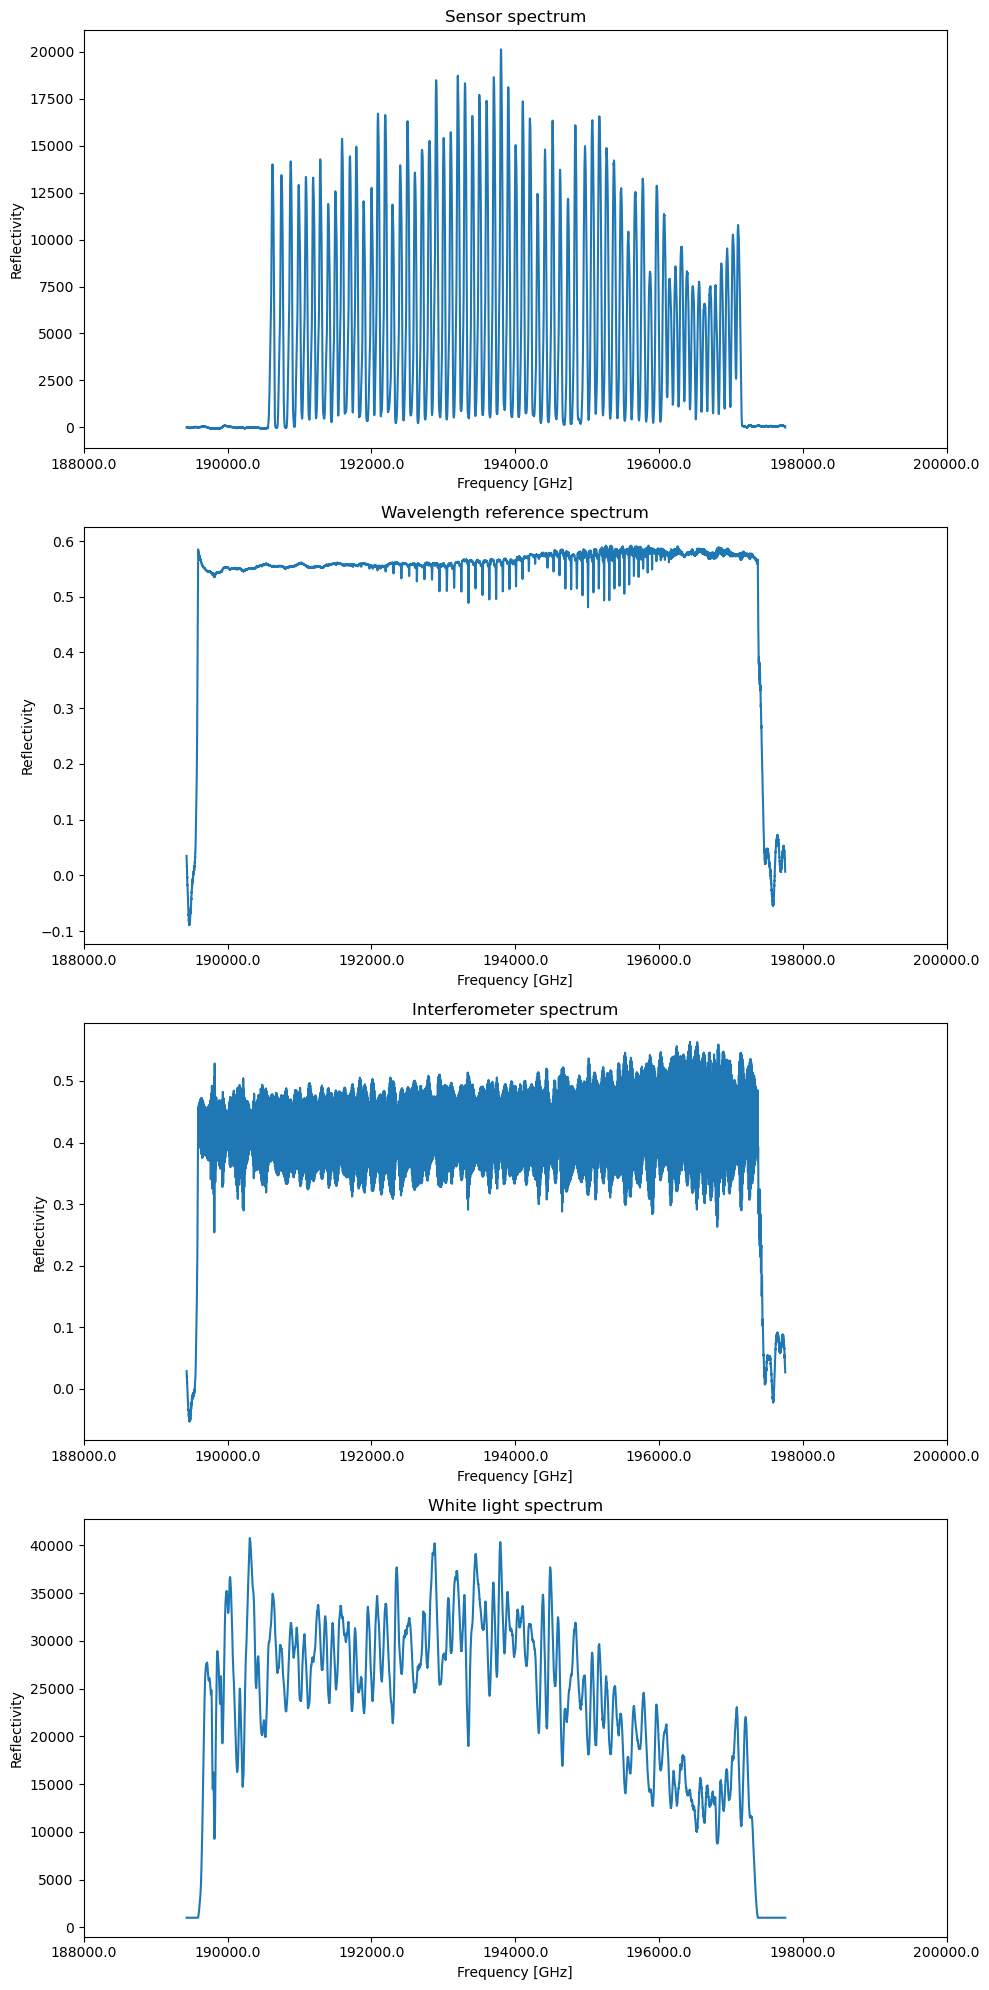

In [10]:
import matplotlib.pyplot as plt

spectrum1 = client.custom_api_request(pyWistom.COMMAND_ID['GET'], b'WSNS', b'DATA', bytes.fromhex("0a01"))
spectrum2 = client.custom_api_request(pyWistom.COMMAND_ID['GET'], b'WSNS', b'DATA', bytes.fromhex("0a02"))
spectrum3 = client.custom_api_request(pyWistom.COMMAND_ID['GET'], b'WSNS', b'DATA', bytes.fromhex("0a03"))
spectrum4 = client.custom_api_request(pyWistom.COMMAND_ID['GET'], b'WSNS', b'DATA', bytes.fromhex("0a04"))
spectrum5 = client.custom_api_request(pyWistom.COMMAND_ID['GET'], b'WSNS', b'DATA', bytes.fromhex("0a05"))

# Extract spectrum data values
spectrum_data_values1 = spectrum1['response']['spectrum_data_values']
spectrum_data_values2 = spectrum2['response']['spectrum_data_values']
spectrum_data_values3 = spectrum3['response']['spectrum_data_values']
spectrum_data_values4 = spectrum4['response']['spectrum_data_values']
spectrum_data_values5 = spectrum5['response']['spectrum_data_values']
# Plot all 5 spectrographs
fig, axs = plt.subplots(4, 1, figsize=(10, 20))

axs[0].plot(spectrum_data_values5, spectrum_data_values1)
axs[0].set_title('Sensor spectrum')

axs[1].plot(spectrum_data_values5, spectrum_data_values2)
axs[1].set_title('Wavelength reference spectrum')

axs[2].plot(spectrum_data_values5, spectrum_data_values3)
axs[2].set_title('Interferometer spectrum')

axs[3].plot(spectrum_data_values5, spectrum_data_values4)
axs[3].set_title('White light spectrum')

for ax in axs:
    ax.set_xlabel('Frequency [GHz]')
    ax.set_ylabel('Reflectivity')
    ax.ticklabel_format(style='plain', axis='x', useOffset=False)  # Ensure x-axis shows plain numbers
    ax.set_xticks([tick for tick in ax.get_xticks()])  # Update x-ticks
    ax.set_xticklabels([f'{tick / 1e9:.1f}' for tick in ax.get_xticks()])  # Convert Hz to GHz

plt.tight_layout()
plt.show()


In [11]:
client.custom_api_request(pyWistom.COMMAND_ID['GET'], b'LGIN', b'SINF', b'')

{'header': {'GET Response': 'LGIN SINF',
  'Token': '13',
  'data_length': '36',
  'data_length_measured': '36'},
 'response': {'logged_in_users': 3,
  'users': {'user_1': 'admin',
   'process_id_1': 36,
   'user_2': 'admin',
   'process_id_2': 39,
   'user_3': 'admin',
   'process_id_3': 43}}}

In [12]:
client.custom_api_request(pyWistom.COMMAND_ID['GET'], b'LGIN', b'UINF', b'\x01admin\x00')

{'header': {'GET Response': 'LGIN UINF',
  'Token': '14',
  'data_length': '17',
  'data_length_measured': '17'},
 'response': {}}

In [13]:
client.custom_api_request(pyWistom.COMMAND_ID['GET'], b'LGIN', b'UINF', b'\x01admin\x00')

{'header': {'GET Response': 'LGIN UINF',
  'Token': '15',
  'data_length': '17',
  'data_length_measured': '17'},
 'response': {}}

In [14]:
spectrum_data = client.custom_api_request(pyWistom.COMMAND_ID['GET'], b'WSNS', b'DATA', b'\x0a\x01')

b'\n\x01'


In [15]:
client.custom_api_request(pyWistom.COMMAND_ID['GET'], b'WSNS', b'PARA', b'')


{'header': {'GET Response': 'WSNS PARA',
  'Token': '17',
  'data_length': '516',
  'data_length_measured': '516'},
 'response': {'lut_enabled': 0,
  'peak_height_reference_lines': 0.035,
  'frequency_delta': 35000000000.0,
  'filter_constant': 0.10000000000000003,
  'white_light_minimum': 1000.0,
  'interferometer_start_amplitude': 0.005,
  'interferometer_minimum_step': 1,
  'reference_averages': 1024,
  'port_1_threshold': 0.12226492075901572,
  'port_2_threshold': 0.04,
  'port_3_threshold': 0.04,
  'port_4_threshold': 0.04,
  'port_5_threshold': 0.04,
  'port_6_threshold': 0.04,
  'port_7_threshold': 0.04,
  'port_8_threshold': 0.04,
  'port_9_threshold': 0.15015344078727527,
  'port_10_threshold': 0.2,
  'port_11_threshold': 0.2,
  'port_12_threshold': 0.04,
  'port_13_threshold': 0.04,
  'port_14_threshold': 0.2,
  'port_15_threshold': 0.07118753002400949,
  'port_16_threshold': 0.2,
  'port_17_threshold': 0.2,
  'port_18_threshold': 0.2,
  'port_19_threshold': 0.2,
  'port_20_t